train images: 2594
val images: 100
n_trainable_params: 14788929, n_nontrainable_params: 0
training arguments:
>>> impath: shoe_dataset
>>> imsize: 256
>>> aug_prob: 0.5
>>> batch_size: 16
>>> num_epoch: 20
>>> optimizer: <class 'torch.optim.adam.Adam'>
>>> lr: 0.001
>>> l2reg: 1e-05
>>> use_bilinear: False
>>> inference: False
>>> use_crf: False
>>> checkpoint: None
>>> backend: False
>>> prefetch: False
>>> device: cpu
>>> multi_gpu: off
>>> model_name: unet
>>> impaths: {'train': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1-2_Training_Input', 'val': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1-2_Validation_Input', 'test': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1-2_Test_Input', 'btrain': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1_Training_GroundTruth', 'bval': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1_Validation_GroundTruth'}
[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 163/163 100.00%
1/20 > train 

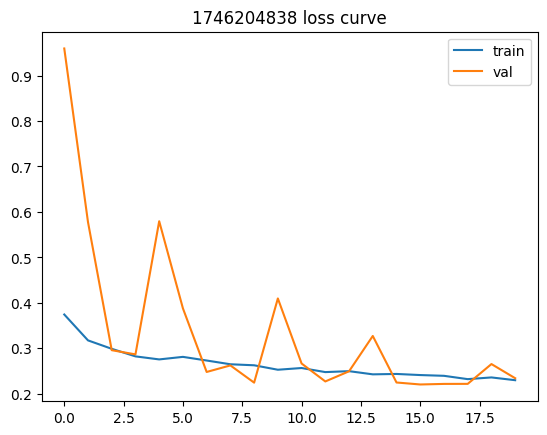

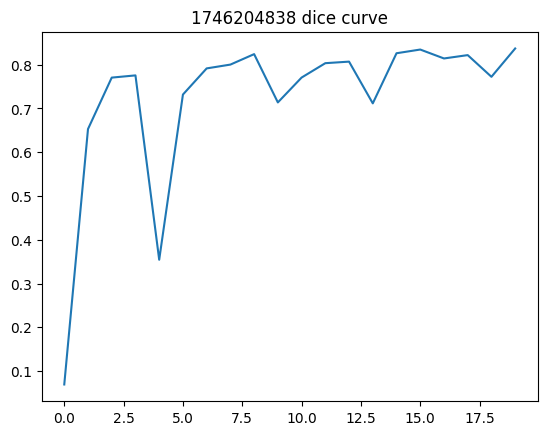

In [1]:
import os
import sys
import time
import torch
import argparse
import matplotlib as mpl
import matplotlib.pyplot as plt
from model import UNet
from loss_func import BCELoss2d, dice_coeff
from data_utils import ImageDataset, TestImageDataset
from torch.utils.data import DataLoader

class Instructor:
    ''' Model training and evaluation '''
    def __init__(self, opt):
        self.opt = opt
        if opt.inference:
            self.testset = TestImageDataset(fdir=opt.impaths['test'], imsize=opt.imsize)
        else:
            self.trainset = ImageDataset(fdir=opt.impaths['train'], bdir=opt.impaths['btrain'], imsize=opt.imsize, mode='train', aug_prob=opt.aug_prob, prefetch=opt.prefetch)
            self.valset = ImageDataset(fdir=opt.impaths['val'], bdir=opt.impaths['bval'], imsize=opt.imsize, mode='val', aug_prob=opt.aug_prob, prefetch=opt.prefetch)
        self.model = UNet(n_channels=3, n_classes=1, bilinear=self.opt.use_bilinear)
        if opt.checkpoint:
            self.model.load_state_dict(torch.load('./state_dict/{:s}'.format(opt.checkpoint), map_location=self.opt.device))
            print('checkpoint {:s} has been loaded'.format(opt.checkpoint))
        if opt.multi_gpu == 'on':
            self.model = torch.nn.DataParallel(self.model)
        self.model = self.model.to(opt.device)
        self._print_args()
    
    def _print_args(self):
        n_trainable_params, n_nontrainable_params = 0, 0
        for p in self.model.parameters():
            n_params = torch.prod(torch.tensor(p.shape))
            if p.requires_grad:
                n_trainable_params += n_params
            else:
                n_nontrainable_params += n_params
        self.info = 'n_trainable_params: {0}, n_nontrainable_params: {1}\n'.format(n_trainable_params, n_nontrainable_params)
        self.info += 'training arguments:\n' + '\n'.join(['>>> {0}: {1}'.format(arg, getattr(self.opt, arg)) for arg in vars(self.opt)])
        if self.opt.device.type == 'cuda':
            print('cuda memory allocated:', torch.cuda.memory_allocated(opt.device.index))
        print(self.info)
    
    def _reset_records(self):
        self.records = {
            'best_epoch': 0,
            'best_dice': 0,
            'train_loss': list(),
            'val_loss': list(),
            'val_dice': list(),
            'checkpoints': list()
        }
    
    def _update_records(self, epoch, train_loss, val_loss, val_dice):
        if val_dice > self.records['best_dice']:
            path = './state_dict/{:s}_dice{:.4f}_temp{:s}.pt'.format(self.opt.model_name, val_dice, str(time.time())[-6:])
            if self.opt.multi_gpu == 'on':
                torch.save(self.model.module.state_dict(), path)
            else:
                torch.save(self.model.state_dict(), path)
            self.records['best_epoch'] = epoch
            self.records['best_dice'] = val_dice
            self.records['checkpoints'].append(path)
        self.records['train_loss'].append(train_loss)
        self.records['val_loss'].append(val_loss)
        self.records['val_dice'].append(val_dice)
    
    def _draw_records(self):
        timestamp = str(int(time.time()))
        print('best epoch: {:d}'.format(self.records['best_epoch']))
        print('best train loss: {:.4f}, best val loss: {:.4f}'.format(min(self.records['train_loss']), min(self.records['val_loss'])))
        print('best val dice {:.4f}'.format(self.records['best_dice']))
        os.rename(self.records['checkpoints'][-1], './state_dict/{:s}_dice{:.4f}_save{:s}.pt'.format(self.opt.model_name, self.records['best_dice'], timestamp))
        for path in self.records['checkpoints'][0:-1]:
            os.remove(path)
        # Draw figures
        plt.figure()
        trainloss, = plt.plot(self.records['train_loss'])
        valloss, = plt.plot(self.records['val_loss'])
        plt.legend([trainloss, valloss], ['train', 'val'], loc='upper right')
        plt.title('{:s} loss curve'.format(timestamp))
        plt.savefig('./figs/{:s}_loss.png'.format(timestamp), format='png', transparent=True, dpi=300)
        plt.figure()
        valdice, = plt.plot(self.records['val_dice'])
        plt.title('{:s} dice curve'.format(timestamp))
        plt.savefig('./figs/{:s}_dice.png'.format(timestamp), format='png', transparent=True, dpi=300)
        # Save report
        report = '\t'.join(['val_dice', 'train_loss', 'val_loss', 'best_epoch', 'timestamp'])
        report += "\n{:.4f}\t{:.4f}\t{:.4f}\t{:d}\t{:s}\n{:s}".format(self.records['best_dice'], min(self.records['train_loss']), min(self.records['val_loss']), self.records['best_epoch'], timestamp, self.info)
        with open('./logs/{:s}_log.txt'.format(timestamp), 'w') as f:
            f.write(report)
        print('report saved:', './logs/{:s}_log.txt'.format(timestamp))
    
    def _train(self, train_dataloader, criterion, optimizer):
        self.model.train()
        train_loss, n_total, n_batch = 0, 0, len(train_dataloader)
        for i_batch, sample_batched in enumerate(train_dataloader):
            inputs, target = sample_batched[0].to(self.opt.device), sample_batched[1].to(self.opt.device)
            predict = self.model(inputs)
            
            optimizer.zero_grad()
            loss = criterion(predict, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(sample_batched)
            n_total += len(sample_batched)
            
            ratio = int((i_batch+1)*50/n_batch)
            sys.stdout.write("\r["+">"*ratio+" "*(50-ratio)+"] {}/{} {:.2f}%".format(i_batch+1, n_batch, (i_batch+1)*100/n_batch))
            sys.stdout.flush()
        print()
        return train_loss / n_total
    
    def _evaluation(self, val_dataloader, criterion):
        self.model.eval()
        val_loss, val_dice, n_total = 0, 0, 0
        with torch.no_grad():
            for sample_batched in val_dataloader:
                inputs, target = sample_batched[0].to(self.opt.device), sample_batched[1].to(self.opt.device)
                predict = self.model(inputs)
                loss = criterion(predict, target)
                dice = dice_coeff(predict, target)
                val_loss += loss.item() * len(sample_batched)
                val_dice += dice.item() * len(sample_batched)
                n_total += len(sample_batched)
        return val_loss / n_total, val_dice / n_total
    
    def run(self):
        _params = filter(lambda p: p.requires_grad, self.model.parameters())
        optimizer = torch.optim.Adam(_params, lr=self.opt.lr, weight_decay=self.opt.l2reg)
        criterion = BCELoss2d()
        train_dataloader = DataLoader(dataset=self.trainset, batch_size=self.opt.batch_size, shuffle=True)
        val_dataloader = DataLoader(dataset=self.valset, batch_size=self.opt.batch_size, shuffle=False)
        self._reset_records()
        for epoch in range(self.opt.num_epoch):
            train_loss = self._train(train_dataloader, criterion, optimizer)
            val_loss, val_dice = self._evaluation(val_dataloader, criterion)
            self._update_records(epoch, train_loss, val_loss, val_dice)
            print('{:d}/{:d} > train loss: {:.4f}, val loss: {:.4f}, val dice: {:.4f}'.format(epoch+1, self.opt.num_epoch, train_loss, val_loss, val_dice))
        self._draw_records()
    
    def inference(self):
        test_dataloader = DataLoader(dataset=self.testset, batch_size=1, shuffle=False)
        n_batch = len(test_dataloader)
        with torch.no_grad():
            for i_batch, sample_batched in enumerate(test_dataloader):
                index, inputs = sample_batched[0], sample_batched[1].to(self.opt.device)
                predict = self.model(inputs)
                self.testset.save_img(index.item(), predict, self.opt.use_crf)
                ratio = int((i_batch+1)*50/n_batch)
                sys.stdout.write("\r["+">"*ratio+" "*(50-ratio)+"] {}/{} {:.2f}%".format(i_batch+1, n_batch, (i_batch+1)*100/n_batch))
                sys.stdout.flush()
        print()
    

if __name__ == '__main__':
    
    optimizers = {
        'adadelta': torch.optim.Adadelta,  # default lr=1.0
        'adagrad': torch.optim.Adagrad,    # default lr=0.01
        'adam': torch.optim.Adam,          # default lr=0.001
        'adamax': torch.optim.Adamax,      # default lr=0.002
        'asgd': torch.optim.ASGD,          # default lr=0.01
        'rmsprop': torch.optim.RMSprop,    # default lr=0.01
        'sgd': torch.optim.SGD,            # default lr=0.1
    }

    # Bypass the automatic argument parsing in Jupyter
    if 'ipykernel_launcher' in sys.argv[0]:
        sys.argv = ['']  # Clear out the existing args
    
    # Hyperparameters
    parser = argparse.ArgumentParser()
    ''' For dataset '''
    parser.add_argument('--impath', default='shoe_dataset', type=str)
    parser.add_argument('--imsize', default=256, type=int)
    parser.add_argument('--aug_prob', default=0.5, type=float)
    ''' For training '''
    parser.add_argument('--batch_size', default=16, type=int)
    parser.add_argument('--num_epoch', default=20, type=int) #number of epochs
    parser.add_argument('--optimizer', default='adam', type=str)
    parser.add_argument('--lr', default=1e-3, type=float)
    parser.add_argument('--l2reg', default=1e-5, type=float)
    parser.add_argument('--use_bilinear', default=False, type=float)
    ''' For inference '''
    parser.add_argument('--inference', default=False, type=bool)
    parser.add_argument('--use_crf', default=False, type=bool)
    parser.add_argument('--checkpoint', default=None, type=str)
    ''' For environment '''
    parser.add_argument('--backend', default=False, type=bool)
    parser.add_argument('--prefetch', default=False, type=bool)
    parser.add_argument('--device', default=None, type=str, help='cpu, cuda')
    parser.add_argument('--multi_gpu', default=None, type=str, help='on, off')
    opt = parser.parse_args()
    
    opt.model_name = 'unet_bilinear' if opt.use_bilinear else 'unet'
    opt.optimizer = optimizers[opt.optimizer]
    opt.device = torch.device(opt.device) if opt.device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    opt.multi_gpu = opt.multi_gpu if opt.multi_gpu else 'on' if torch.cuda.device_count() > 1 else 'off'
    
    '''opt.impaths = {
        'train': os.path.join('.', opt.impath, 'train'),
        'val': os.path.join('.', opt.impath, 'val'),
        'test': os.path.join('.', opt.impath, 'test'),
        'btrain': os.path.join('.', opt.impath, 'bg', 'train'),
        'bval': os.path.join('.', opt.impath, 'bg', 'val')
    }'''

    opt.impaths = {
        'train': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1-2_Training_Input',  # Path to training images
        'val': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1-2_Validation_Input',      # Path to validation images
        'test': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1-2_Test_Input',    # Path to test images
        'btrain': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1_Training_GroundTruth',  # Path to training masks
        'bval': 'C:/Users/Fourth/data/SEGMENTATION DATA SET/ISIC2018_Task1_Validation_GroundTruth'       # Path to validation masks
    }

    for folder in ['figs', 'logs', 'state_dict', 'predicts']:
        if not os.path.exists(folder):
            os.mkdir(folder)
    
    if opt.backend: # Disable the matplotlib window
        mpl.use('Agg')
    
    ins = Instructor(opt)
    if opt.inference:
        ins.inference()
    else:
        ins.run()
